<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/main/RA1_TP2/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_2%2C_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2 — Análisis Exploratorio de Datos



---
#Ejercicio 1: Comprensión inicial de datos reales

---
**Dataset:** `propiedades.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta Axel, Bareiro Santiago, Borges Agustin  
**Fecha:** xx/03/2026

>Una empresa inmobiliaria desea comprender mejor el mercado de viviendas de su región. Para apoyar sus decisiones comerciales, cuenta con un registro histórico de propiedades que incluye variables como precio de venta, superficie total, cantidad de habitaciones, antigüedad del inmueble, barrrio, entre otras.
>
>El dataset se encuentra en el archivo adjunto denominado **"propiedades.csv"**.
>
>El objetivo de este ejercicio es realizar una exploración incial completa del dataset.

---
##0. Configuracion del entorno

In [327]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

# Detectar Google Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Ejecución en Google Colab. Clonando repositorio...")
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", "https://github.com/AxelSkrauba/applied-ai-engineering.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

# Importar utilidades globales
from utils.plots import setup_plot_style
setup_plot_style()

Ejecución en Google Colab. Clonando repositorio...


In [328]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore') # Mantenemos los logs limpios

datasetPropiedades = pd.read_csv("/content/propiedades.csv")


---

## 1. Carga y primera inspección

In [329]:
print("Primeras 10 filas del dataset:\n")
datasetPropiedades.head(10)

Primeras 10 filas del dataset:



,id,precio,superficie_m2,habitaciones,antiguedad_años,barrio,precio_m2
0,1,648900.0,232.9,6,5.0,Palermo,2786.17
1,2,210000.0,190.1,6,1.0,Sur,1104.68
2,3,254800.0,103.6,4,18.0,Belgrano,2459.46
3,4,594000.0,189.2,6,4.0,Palermo,3139.53
4,5,170200.0,90.6,2,45.0,Centro,1878.59
5,6,301300.0,100.6,3,29.0,Recoleta,2995.03
6,7,161000.0,49.3,2,1.0,Palermo,3265.72
7,8,309100.0,112.0,5,50.0,Palermo,2759.82
8,9,175500.0,93.0,2,27.0,Centro,1887.10
9,10,43200.0,44.0,2,41.0,Sur,981.82


Al mirar las primeras 10 muestras del dataset se observó que las **filas** representan un registro histórico único de una propiedad inmobiliaria particular puesta a la venta en la región.


Por otro lado cada **columna** representa una característica o atributo específico de esa propiedad (como el precio de venta o superficie total por ejemplo). La columna `id` es simplemente un identificador único para cada registro.

In [330]:
# Resumen de los tipos de datos y recuento de valores no nulos
datasetPropiedades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               800 non-null    int64  
 1   precio           768 non-null    float64
 2   superficie_m2    800 non-null    float64
 3   habitaciones     800 non-null    int64  
 4   antiguedad_años  752 non-null    float64
 5   barrio           800 non-null    object 
 6   precio_m2        768 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 43.9+ KB


Haciendo uso del metodo `.info()` se evidencian 800 instancias (`entries`, filas) y 7 variables (columnas).


A simple vista se detecta que tipos de variables presentes son los siguientes:

*   `id`: Identificador único.
*   `precio`, `superficie_m2`, `precio_m2`, `antiguedad_años`: variables numericas continuas.
*   `habitaciones`: variable numerica discreta.
*   `barrio`: variable categórica.


En el contexto de un Análisis Explotariorio de Datos (EDA) inicial para un mercado inmobiliario regional, 800 observaciones es un volumen estadísticamente decente. Esta cantidad nos permite realizar agrupaciones decente. Esta cantidad nos permite realizar agrupaciones, calcular medidas de tendencia central, de dispersión de confianza, y construir una intuición analítica sólida sin que valores extremos (outliers) distorsiones fuertemente las conclusiones generales.

Tambien, podemos apreciar que no todas las variables tienen un tipo de dato adecuado del todo. Si bien las variables continuas (`precio`, `superficie_m2`, `precio_m2`) y categóricas (`barrio`) tienen tipos de datos computacionales correctos (float64 y object), se detectó una discrepancia en la variable `antiguedad_años`.

Desde la teoría estadística, la antigúedad en años es una variable **numérica discreta**, por lo que su tipo computacional ideal debería ser entero (`int64`). Sin embargo, el método `.info()` revela que está cargada como `float64`.

Nuestra hipótesis es que esta anomalía se debe a la presencia de valores nulos en dicha columna (solo posee 752 valores no nulos sobre 800). En la arquitectura de Pandas, la inclusión de valores `NaN` fuerza a que toda columna convierta a punto flotante. para corregir este tipo de dato, primero se deberá tomar una decisión sobre cómo tratar o imputar estos valores faltantes en la etapa de Calidad de Datos.


---
##2. Calidad de los datos

###2.1 Valores Faltantes

In [331]:
datasetPropiedades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               800 non-null    int64  
 1   precio           768 non-null    float64
 2   superficie_m2    800 non-null    float64
 3   habitaciones     800 non-null    int64  
 4   antiguedad_años  752 non-null    float64
 5   barrio           800 non-null    object 
 6   precio_m2        768 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 43.9+ KB


In [332]:
faltantes = datasetPropiedades.isnull().sum()
pct_faltantes = (faltantes / len(datasetPropiedades) * 100).round(2)

resumen_faltantes = pd.DataFrame({
    "Cantidad": faltantes,
    "Porcentaje (%)": pct_faltantes
}).query("Cantidad > 0")

print("Variables con valores faltantes:")
print(resumen_faltantes)


Variables con valores faltantes:
                 Cantidad  Porcentaje (%)
precio                 32             4.0
antiguedad_años        48             6.0
precio_m2              32             4.0



Existen valores nulos en dos variables:
- `precio`: **32 valores faltantes (4%)**.
- `antiguedad_años`: **48 valores faltantes (6%)**.
- `precio_m2` hereda los faltantes de `precio` por ser una variable derivada.

###2.2 Detección de valores inconsistentes o erróneos

Ahora vamos a verificar si existen valores negativos en las columnas numéricas que no deberían tenerlos, como `precio`, `superficie_m2`, `precio_m2`, `habitaciones` y `antiguedad_años`.

In [333]:
columnas_numericas = ['precio', 'superficie_m2', 'precio_m2', 'antiguedad_años', 'habitaciones']

for col in columnas_numericas:
    if col in datasetPropiedades.columns:
        valores_negativos = datasetPropiedades[datasetPropiedades[col] < 0]
        if not valores_negativos.empty:
            print(f"Se encontraron valores negativos en la columna '{col}':")
            display(valores_negativos)
        else:
            print(f"No se encontraron valores negativos en la columna '{col}'.")
    else:
        print(f"La columna '{col}' no existe en el dataset.")

No se encontraron valores negativos en la columna 'precio'.
No se encontraron valores negativos en la columna 'superficie_m2'.
No se encontraron valores negativos en la columna 'precio_m2'.
No se encontraron valores negativos en la columna 'antiguedad_años'.
No se encontraron valores negativos en la columna 'habitaciones'.


###2.3 Decisiones a tomar frente a valores faltantes

Los modelos de ML matemáticos no saben cómo lidiar con un valor vacío (`NaN` o `Null`). Debemos identificarlos y tomar decisiones informadas sobre qué hacer con ellos.

Para variables numéricas, si son pocas las faltantes se suele **imputar** (rellenar) con la mediana.
Si es categorica y faltan muchos datos se puede imputar con la moda pero se sesgaria mucho los datos, o se puede eliminar las filas con esta información.

Si los valores faltantes son muchos para un tipo de dato no conviene eliminar, si el dato es numerico se puede imputar usando el promedio con los datos que no faltan
Si hay datos atípicos (outliers), en ese caso es mejor utilizar la mediana.
Se puede ignorar algunos datos dependiendo de la lógica, si el dato es piscina y falta el dato que indique si posee o no, indica que no posee, y que no se decidió anotar.


In [334]:
# @title Se decide eliminar los datos con precio faltante y imputar los datos con antiguedad_años nulos con la mediana.
# Aplicar las decisiones de limpieza
datasetPropiedadesClean = datasetPropiedades.dropna(subset=["precio"]).copy()

# Imputar antiguedad con mediana por barrio
datasetPropiedadesClean["antiguedad_años"] = datasetPropiedadesClean.groupby("barrio")["antiguedad_años"].transform(
    lambda x: x.fillna(x.median())
)

# Verificar resultado
print(f"Filas después de eliminar los datos de precio nulos: {len(datasetPropiedadesClean)} (se eliminaron {len(datasetPropiedades) - len(datasetPropiedadesClean)})")
print(f"Faltantes restantes:\n{datasetPropiedadesClean.isnull().sum()}")

Filas después de eliminar los datos de precio nulos: 768 (se eliminaron 32)
Faltantes restantes:
id                 0
precio             0
superficie_m2      0
habitaciones       0
antiguedad_años    0
barrio             0
precio_m2          0
dtype: int64


Análisis de 'superficie_m2' antes de eliminar outliers:


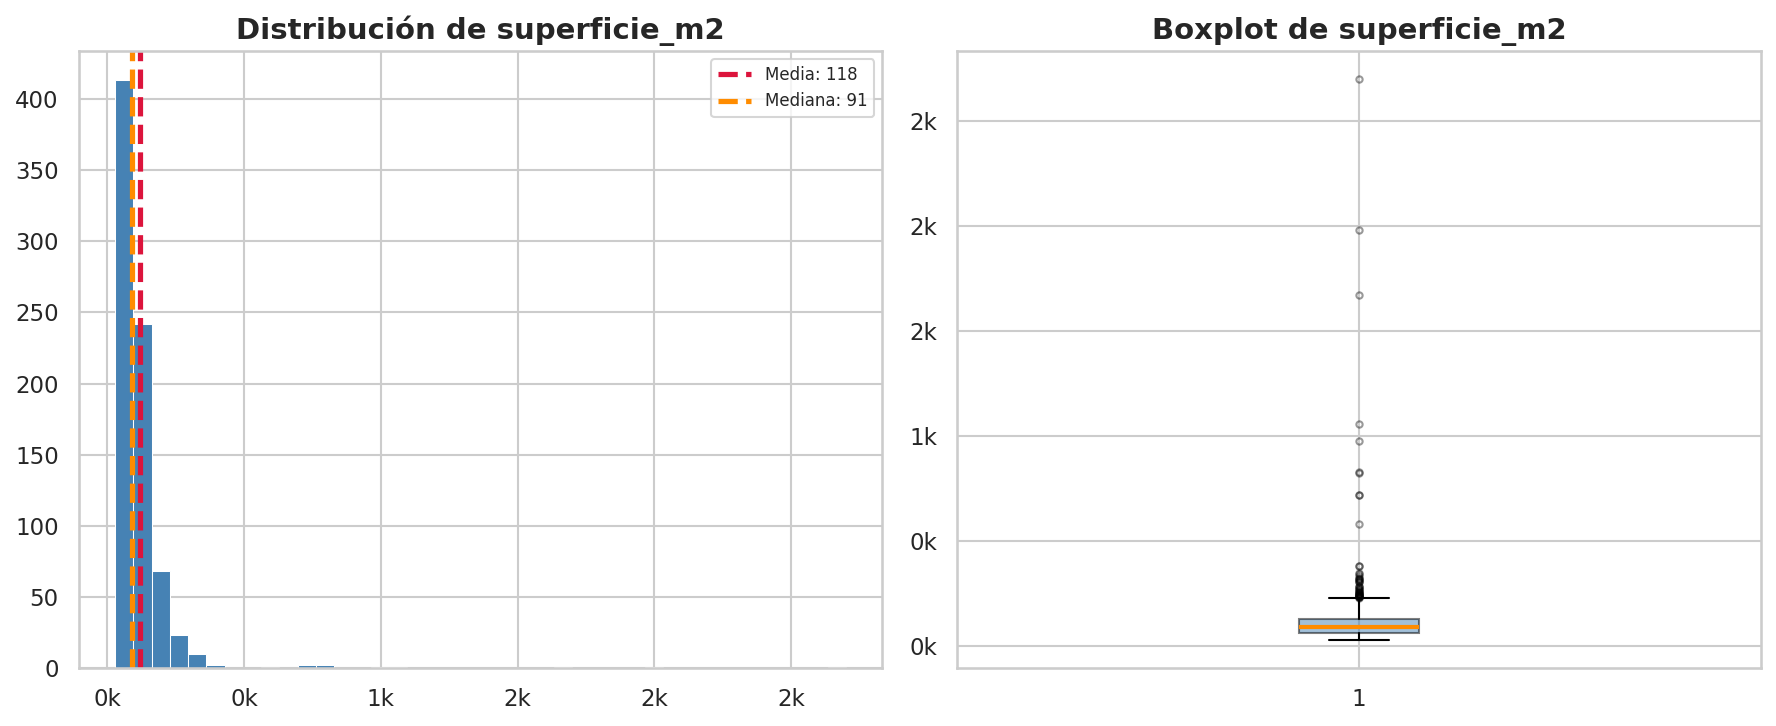

Variable: SUPERFICIE_M2
  > Límite superior IQR: 229.05
  > Límite inferior IQR: -37.95
  > Outliers detectados: 45 (5.9%)
------------------------------

Valores atípicos en 'superficie_m2' y sus precios correspondientes:


,superficie_m2,precio
0,232.9,648900.0
12,241.9,303700.0
68,247.2,505700.0
70,256.6,387400.0
72,236.1,541500.0
76,380.0,543000.0
122,719.0,169600.0
135,279.5,648300.0
155,253.4,682200.0
187,309.0,569600.0



Filas antes de eliminar outliers de 'superficie_m2': 768
Filas después de eliminar outliers de 'superficie_m2': 723
Se eliminaron 45 filas.

Análisis de 'superficie_m2' después de eliminar outliers:


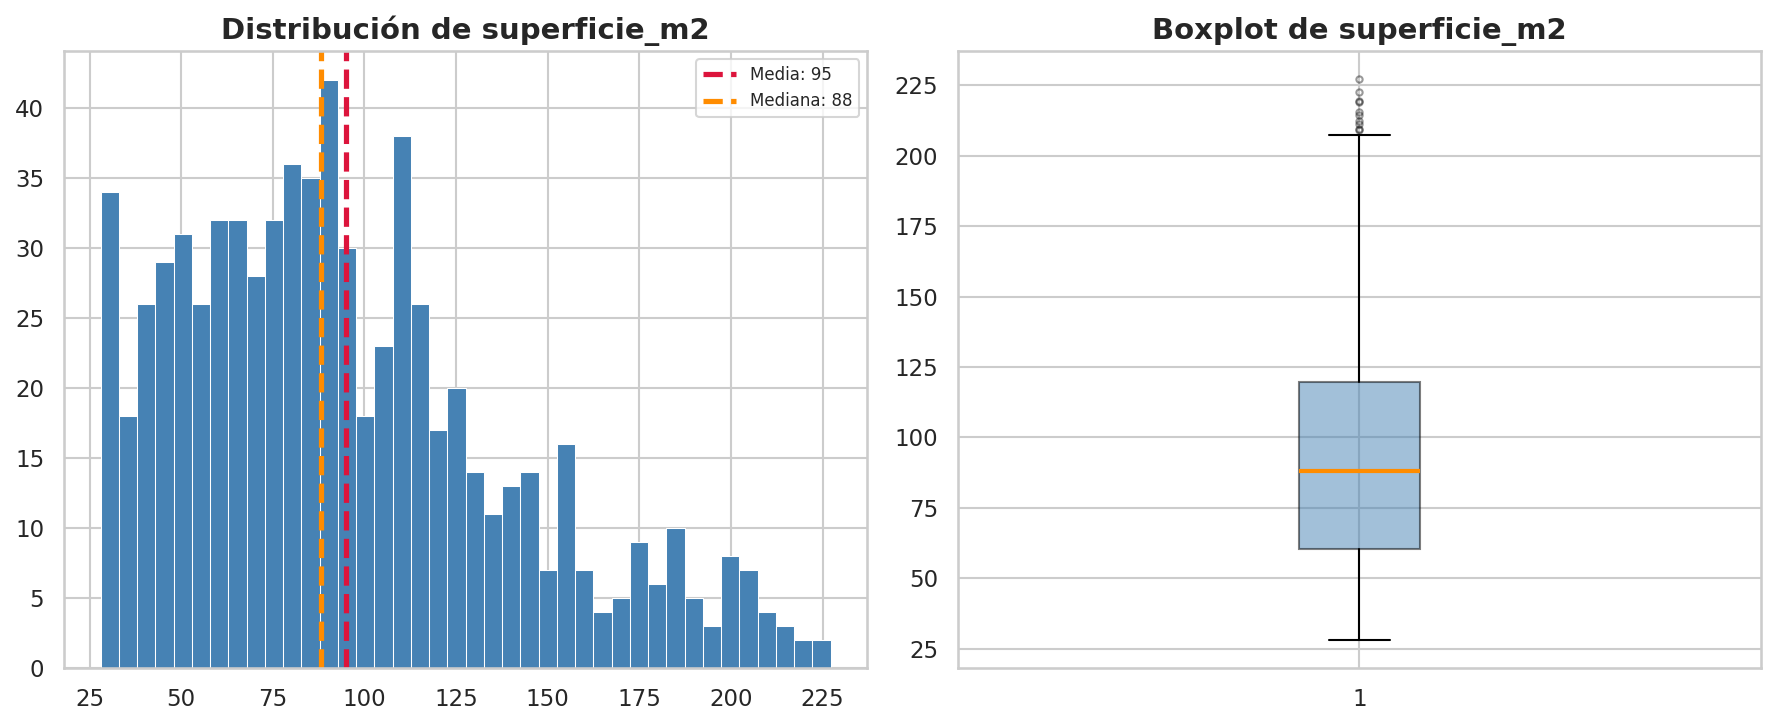

Variable: SUPERFICIE_M2
  > Límite superior IQR: 208.40
  > Límite inferior IQR: -28.40
  > Outliers detectados: 10 (1.4%)
------------------------------


(np.float64(-28.4),
 np.float64(208.39999999999998),
       id    precio  superficie_m2  habitaciones  antiguedad_años     barrio  \
 61    62  240900.0          212.4             6              5.0        Sur   
 133  134  316400.0          215.6             5             24.0      Norte   
 163  164  468300.0          222.7             5              1.0     Centro   
 190  191  183200.0          219.0             5             54.0  Mataderos   
 326  327  567900.0          214.5             5              3.0   Belgrano   
 420  421  321600.0          209.0             6             38.0       Este   
 469  470  233500.0          211.3             6              5.0        Sur   
 472  473  559600.0          227.2             7             25.0     Centro   
 500  501  594600.0          209.6             6             12.0    Palermo   
 507  508  552800.0          219.4             6             11.0   Belgrano   
 
      precio_m2  
 61     1134.18  
 133    1467.53  
 163    210

In [335]:
# @title Esta celda realiza el analisis de superficie y precio, y luego elimina los valores atipicos (outliers)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

def plot_univariate_analysis_and_outliers(data, var, color="steelblue"):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    data_series = data[var].dropna()

    # --- 1. HISTOGRAMA ---
    axes[0].hist(data_series, bins=40, color=color, edgecolor="white", linewidth=0.5)
    mean_val = data_series.mean()
    median_val = data_series.median()
    axes[0].axvline(mean_val, color="crimson", linestyle="--", label=f"Media: {mean_val:,.0f}")
    axes[0].axvline(median_val, color="darkorange", linestyle="--", label=f"Mediana: {median_val:,.0f}")
    axes[0].set_title(f"Distribución de {var}")
    axes[0].legend(fontsize=8)

    # Use FuncFormatter for dynamic scaling of x-axis ticks if values are large
    if data_series.max() > 1000:
        axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

    # --- 2. BOXPLOT ---
    axes[1].boxplot(data_series, vert=True, patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.5),
                       medianprops=dict(color="darkorange", linewidth=2),
                       flierprops=dict(marker="o", markersize=3, alpha=0.4, color="crimson"))
    axes[1].set_title(f"Boxplot de {var}") # Fixed SyntaxError here

    # Use FuncFormatter for dynamic scaling of y-axis ticks if values are large
    if data_series.max() > 1000:
        axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

    plt.tight_layout()
    plt.show()

    # Estadísticas para outliers
    q1 = data_series.quantile(0.25)
    q3 = data_series.quantile(0.75)
    iqr = q3 - q1
    lim_sup = q3 + 1.5 * iqr
    lim_inf = q1 - 1.5 * iqr

    outliers_data = data[(data[var] > lim_sup) | (data[var] < lim_inf)]

    print(f"Variable: {var.upper()}")
    print(f"  > Límite superior IQR: {lim_sup:,.2f}")
    print(f"  > Límite inferior IQR: {lim_inf:,.2f}")
    print(f"  > Outliers detectados: {len(outliers_data)} ({len(outliers_data)/len(data_series)*100:.1f}%)")
    print("-" * 30)
    return lim_inf, lim_sup, outliers_data

# Visualize and get outlier limits and data for 'superficie_m2'
print("Análisis de 'superficie_m2' antes de eliminar outliers:")
lim_inf_superficie, lim_sup_superficie, superficie_outliers = plot_univariate_analysis_and_outliers(datasetPropiedadesClean, 'superficie_m2')

# Display 'superficie_m2' and 'precio' for the identified outliers
if not superficie_outliers.empty:
    print("\nValores atípicos en 'superficie_m2' y sus precios correspondientes:")
    display(superficie_outliers[['superficie_m2', 'precio']])
else:
    print("\nNo se encontraron outliers en 'superficie_m2'.")

# Remove outliers from 'superficie_m2' in datasetPropiedadesClean
initial_rows = len(datasetPropiedadesClean)
datasetPropiedadesClean = datasetPropiedadesClean[
    (datasetPropiedadesClean['superficie_m2'] >= lim_inf_superficie) &
    (datasetPropiedadesClean['superficie_m2'] <= lim_sup_superficie)
].copy()

print(f"\nFilas antes de eliminar outliers de 'superficie_m2': {initial_rows}")
print(f"Filas después de eliminar outliers de 'superficie_m2': {len(datasetPropiedadesClean)}")
print(f"Se eliminaron {initial_rows - len(datasetPropiedadesClean)} filas.")

# Re-visualize to confirm removal
print("\nAnálisis de 'superficie_m2' después de eliminar outliers:")
plot_univariate_analysis_and_outliers(datasetPropiedadesClean, 'superficie_m2')


Acontinuación se muestra la diferencia entre la dataset limpia y se la compara con la dataset original

In [336]:
datasetPropiedades.describe()

,id,precio,superficie_m2,habitaciones,antiguedad_años,precio_m2
count,800.0000,768.000000,800.00000,800.000000,752.000000,768.000000
mean,400.5000,200636.743398,117.63600,3.428750,21.960106,1961.878724
std,231.0844,142582.538365,154.54675,1.625801,18.556668,988.500261
min,1.0000,19900.000000,28.00000,1.000000,0.000000,116.180000
25%,200.7500,102900.000000,62.67500,2.000000,4.000000,1322.425000
50%,400.5000,160000.000000,90.95000,3.000000,18.000000,1841.940000
75%,600.2500,264075.000000,129.27500,5.000000,38.000000,2436.200000
max,800.0000,994200.000000,2700.00000,7.000000,59.000000,10111.360000


In [337]:
datasetPropiedadesClean.describe()

,id,precio,superficie_m2,habitaciones,antiguedad_años,precio_m2
count,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000
mean,396.648686,185488.546238,94.856570,3.305671,21.904564,1992.205795
std,231.054210,118747.184091,44.932936,1.555727,18.053204,981.465760
min,2.000000,19900.000000,28.000000,1.000000,0.000000,631.750000
25%,196.500000,101500.000000,60.400000,2.000000,5.000000,1340.550000
50%,393.000000,155200.000000,88.100000,3.000000,18.000000,1872.160000
75%,597.500000,241500.000000,119.600000,4.000000,37.000000,2424.405000
max,800.000000,874865.510000,227.200000,7.000000,59.000000,10111.360000


---
##3. Estadística Descriptiva

###3.1 Alta variabilidad entre datos



In [338]:
columnas_numericas = datasetPropiedades.select_dtypes(include=['number']).columns

# Calcular la media y la desviación estándar para cada columna numérica
valores_media = datasetPropiedades[columnas_numericas].mean()
valores_desviacion = datasetPropiedades[columnas_numericas].std()

# CV = Desviación Estándar / Media
cv = (valores_desviacion / valores_media)

# Crear un DataFrame para mostrar los resultados de manera ordenada
cv_df = pd.DataFrame({
    'Media': valores_media,
    'Desviación Estándar': valores_desviacion,
    'Coeficiente de Variación': cv
}).sort_values(by='Coeficiente de Variación', ascending=False)

display(cv_df)

,Media,Desviación Estándar,Coeficiente de Variación
superficie_m2,117.636000,154.546750,1.313771
antiguedad_años,21.960106,18.556668,0.845017
precio,200636.743398,142582.538365,0.710650
id,400.500000,231.084400,0.576990
precio_m2,1961.878724,988.500261,0.503854
habitaciones,3.428750,1.625801,0.474167


La variable que presenta mayor variabilidad relativa es la superficie de las viviendas, con un coeficiente de variación (CV) de 1.314, mientras que el CV del resto de variables esta entre 0.45 y 0.85.

###3.2 La mediana y la media, sus diferencias y efectos en la forma de la distribución

In [339]:
# Calcular la media y la mediana para cada columna numérica
median_values = datasetPropiedades[columnas_numericas].median()

# Calcular la diferencia absoluta entre la media y la mediana
diferencia = (valores_media - median_values).abs()

# Calcular la diferencia porcentual
diferencia_porcentual = (diferencia / valores_media) * 100

# Crear un DataFrame para mostrar los resultados
diferencia_df = pd.DataFrame({
    'Media': valores_media,
    'Mediana': median_values,
    'Diferencia Absoluta (Media - Mediana)': diferencia,
    'Diferencia Porcentual (%)': diferencia_porcentual
}).sort_values(by='Diferencia Porcentual (%)', ascending=False)

display(diferencia_df)

,Media,Mediana,Diferencia Absoluta (Media - Mediana),Diferencia Porcentual (%)
superficie_m2,117.636000,90.95,26.686000,22.685232
precio,200636.743398,160000.00,40636.743398,20.253889
antiguedad_años,21.960106,18.00,3.960106,18.033184
habitaciones,3.428750,3.00,0.428750,12.504557
precio_m2,1961.878724,1841.94,119.938724,6.113463
id,400.500000,400.50,0.000000,0.000000


Existe una diferencia significativa entre la media y la mediana en casi todas las variables, principalmente en la superficie, el precio y la antigüedad del mobiliario. Esto es un indicativo de que las distribuciones no son simétricas y están sesgadas. En este caso todas las medianas son menores que las medias, por lo que las distribuciones estan sesgadas hacia la derecha.

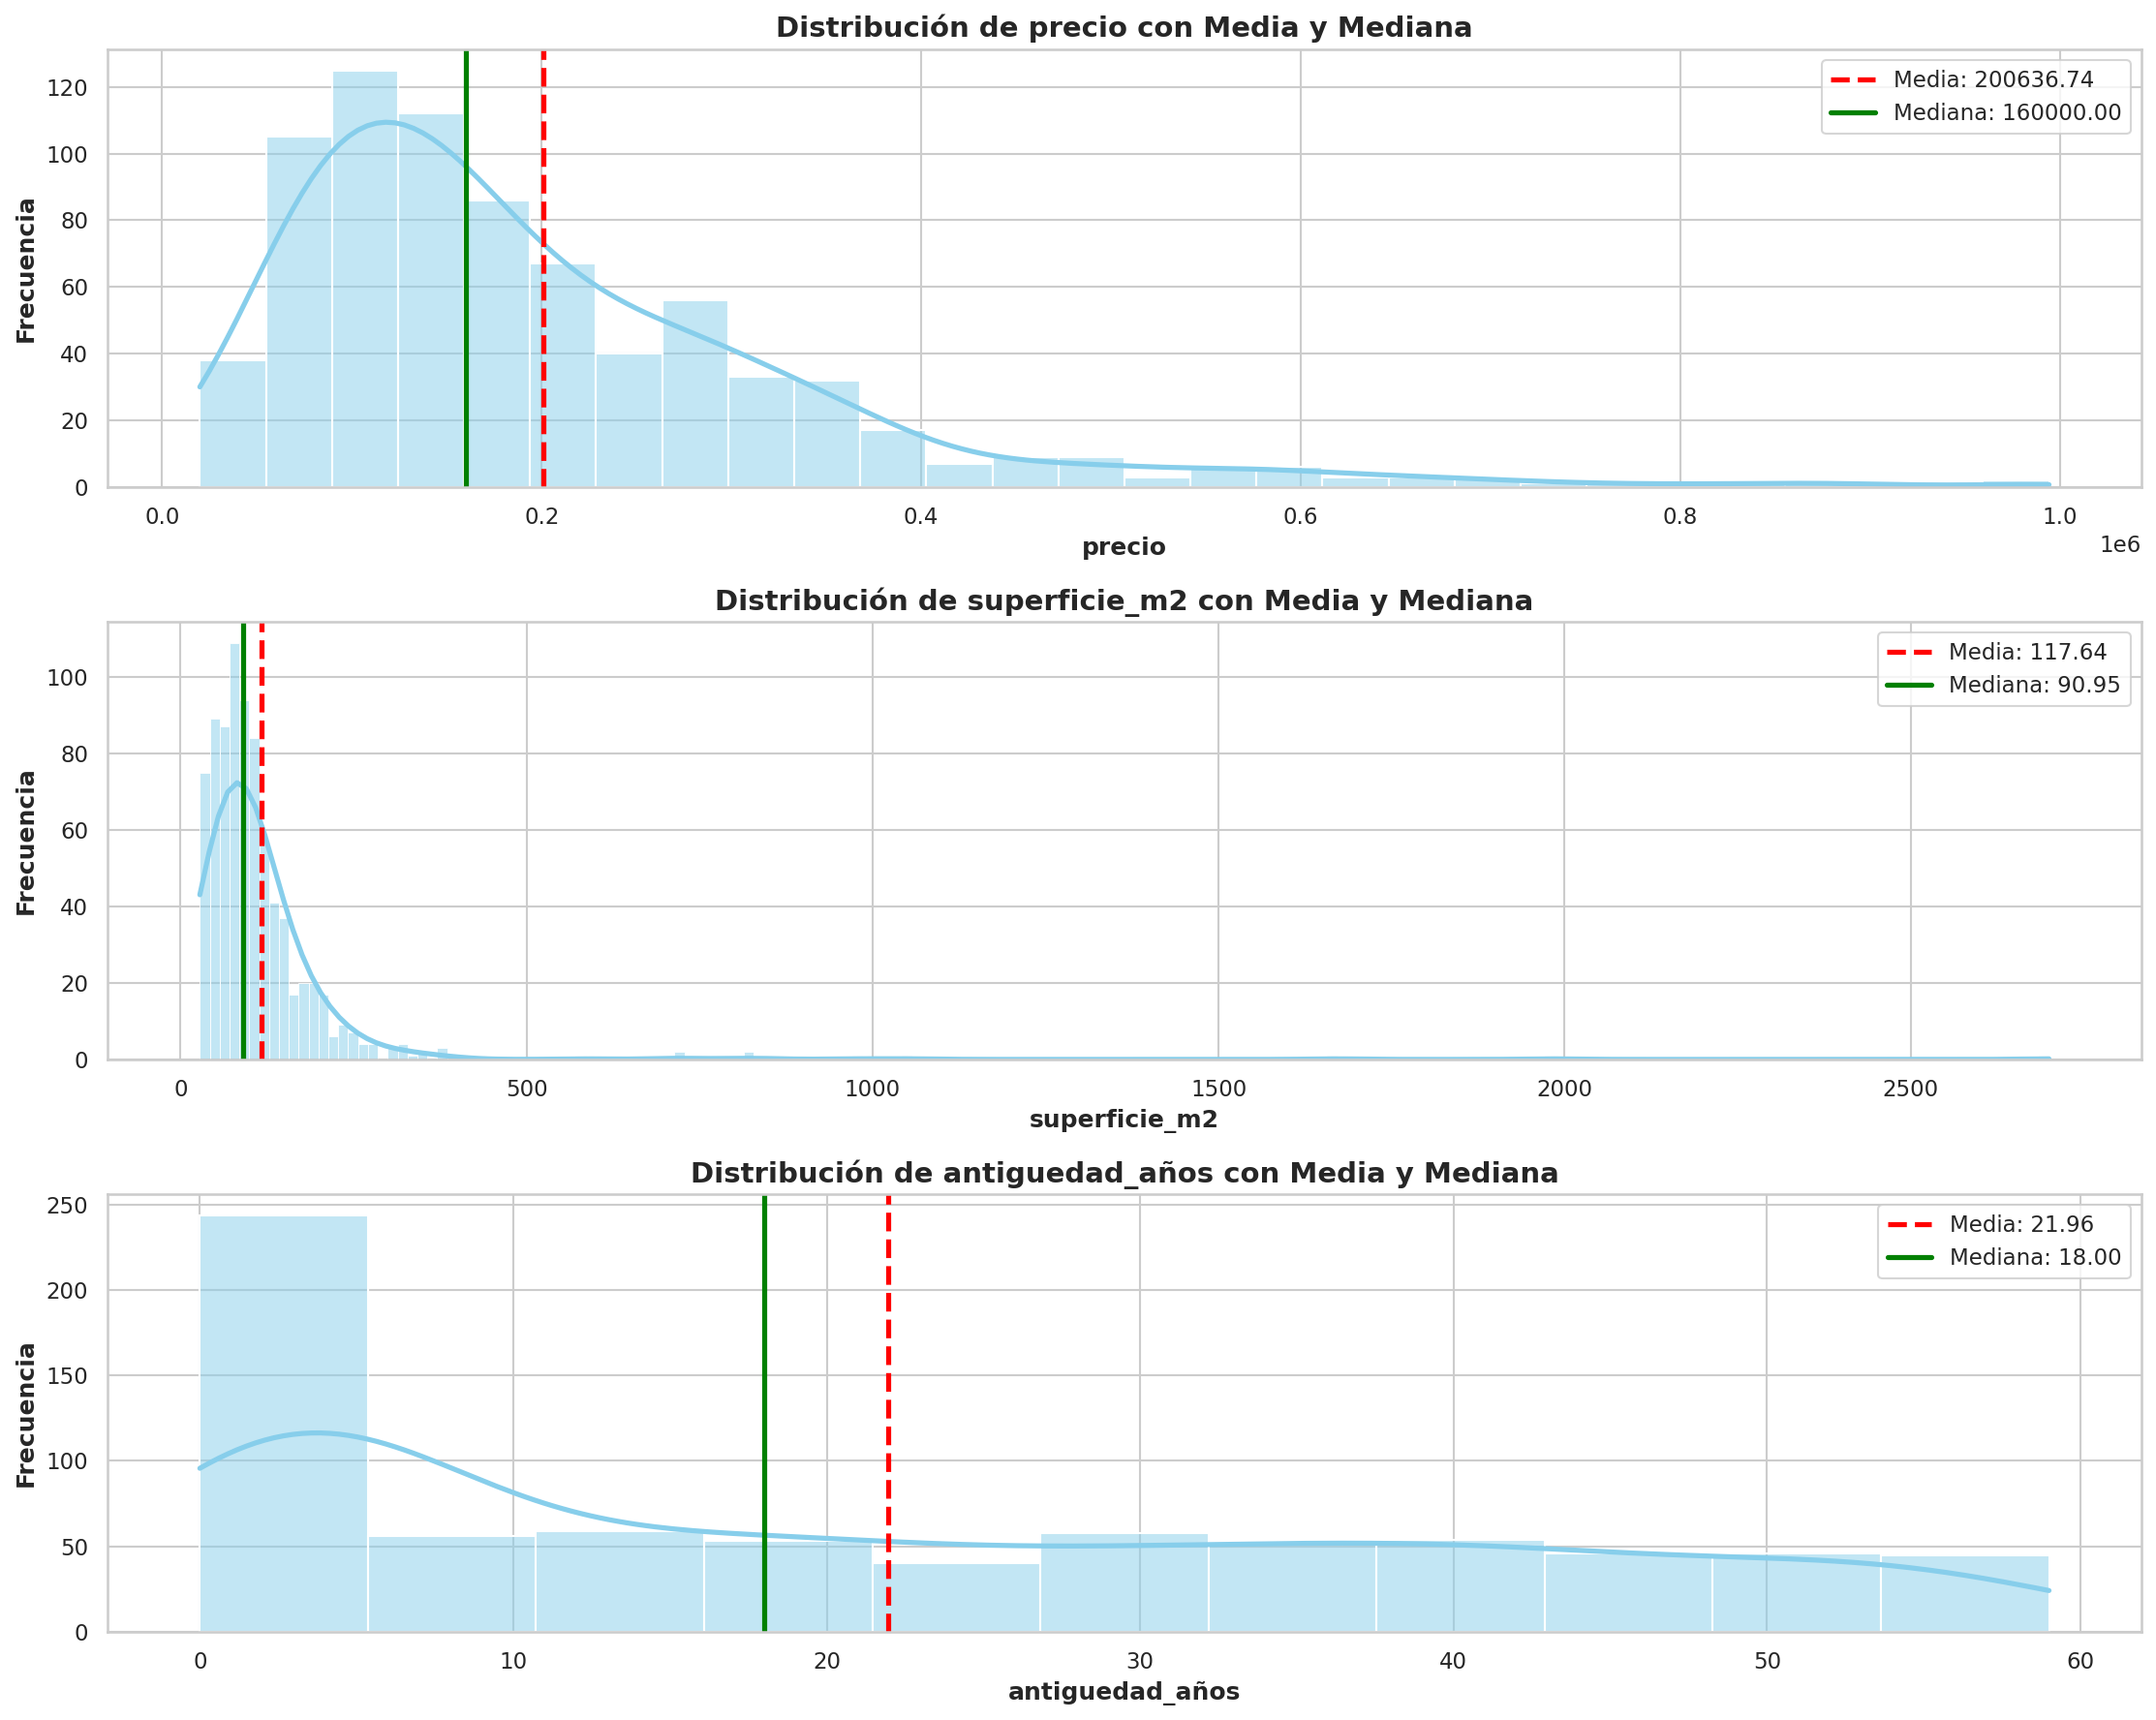

In [340]:
variables_to_plot = ['precio', 'superficie_m2', 'antiguedad_años']

plt.figure(figsize=(15, 12))

for i, var in enumerate(variables_to_plot):
    plt.subplot(3, 1, i + 1)
    sns.histplot(datasetPropiedades[var], kde=True, color='skyblue')

    # Calculate mean and median for the current variable
    mean_val = datasetPropiedades[var].mean()
    median_val = datasetPropiedades[var].median()

    # Add vertical lines for mean and median
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', label=f'Mediana: {median_val:.2f}')

    plt.title(f'Distribución de {var} con Media y Mediana')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.legend()

plt.tight_layout()
plt.show()

Como podemos observar en los histogramas de `precio`, `superficie_m2` y `antiguedad_años`, la línea roja de la media y la línea verde de la mediana no coinciden. La media (roja) se encuentra a la derecha de la mediana (verde) en las tres variables, lo que indica una asimetría positiva o un sesgo hacia la derecha. Esto significa que la mayoría de los valores se concentran en el lado izquierdo de la distribución, pero hay algunos valores extremos altos que "empuja" la media hacia la derecha. Esto se alinea con las observaciones previas de que estas distribuciones no son simétricas y que la mediana es una medida de tendencia central más representativa que la media en estos casos.

###3.3 Similitudes entre distribuciones

Hagamos un enfasis en la grafica anterior de la distribución del precio, y comparemosla con la siguiente grafica de una distribución logaritmica normal.

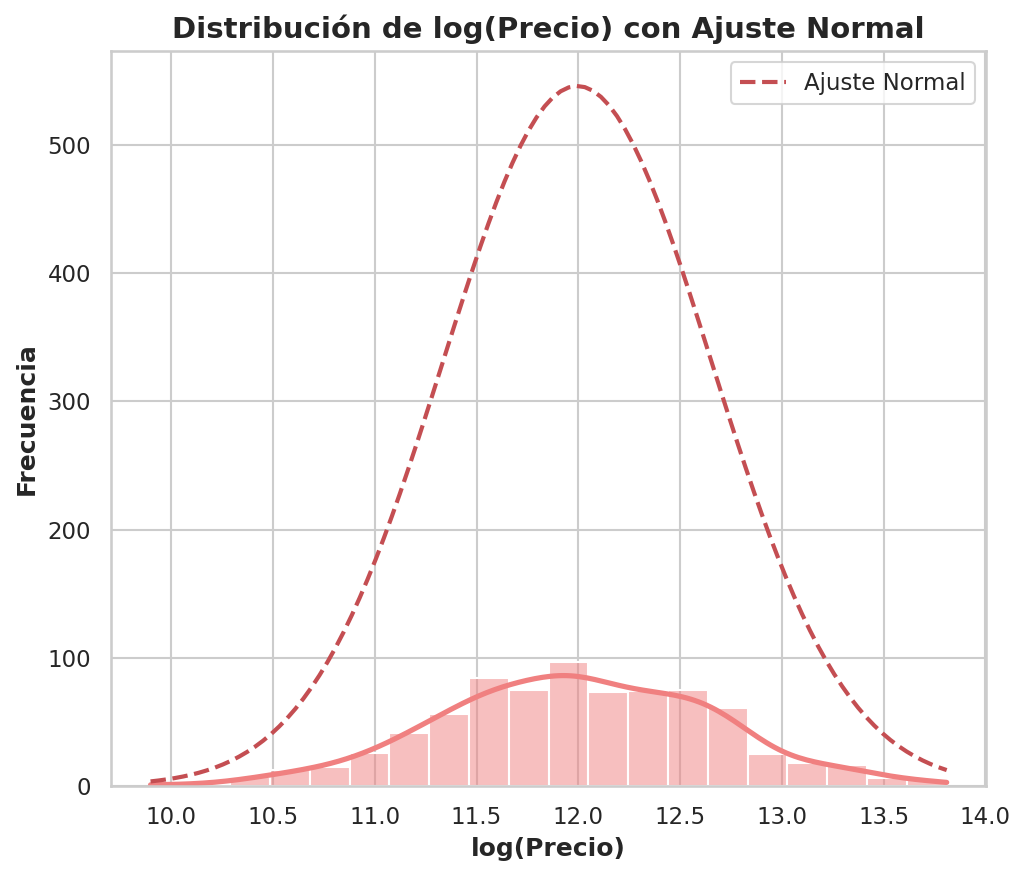

In [341]:
# Eliminar valores nulos de la columna 'precio' para el análisis
datos_precio = datasetPropiedades['precio'].dropna()

# Crear la figura y un subplot para la distribución de log(precio)
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

# Subplot: Distribución de log(precio) y ajuste a una distribución normal
log_precio = np.log(datos_precio)
sns.histplot(log_precio, kde=True, ax=ax, color='lightcoral')

# Ajustar una distribución normal a log_precio
mu, std = norm.fit(log_precio)
x_range = np.linspace(log_precio.min(), log_precio.max(), 100)
p_normal = norm.pdf(x_range, mu, std)

# Escalar la PDF para que se ajuste a la altura del histograma
max_hist_height = ax.patches[0].get_height() if ax.patches else 1
max_pdf_height = p_normal.max()
factor_de_escala = (max_hist_height / max_pdf_height) * (len(log_precio) * (log_precio.max() - log_precio.min()) / len(ax.get_xticks()))

ax.plot(x_range, p_normal * factor_de_escala, 'r--', linewidth=2, label='Ajuste Normal')

ax.set_title('Distribución de log(Precio) con Ajuste Normal')
ax.set_xlabel('log(Precio)')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.show()

Es una distribución con una visible asimetría positiva, y se asemeja a la distribución Log-Normal. Esto representa que hay más propiedades de precios bajos, pero existen algunas de lujo o de precios muy altos (valores atípicos) que elevan el promedio, por lo que en este caso la mediana es una medida de tendencia central mas representativa que la media aritmética.

---
###4 Visualización y detección de outliers

Las tres variables numéricas para su análisis serán `precio`, `superficie_m2` y `precio_m2`.

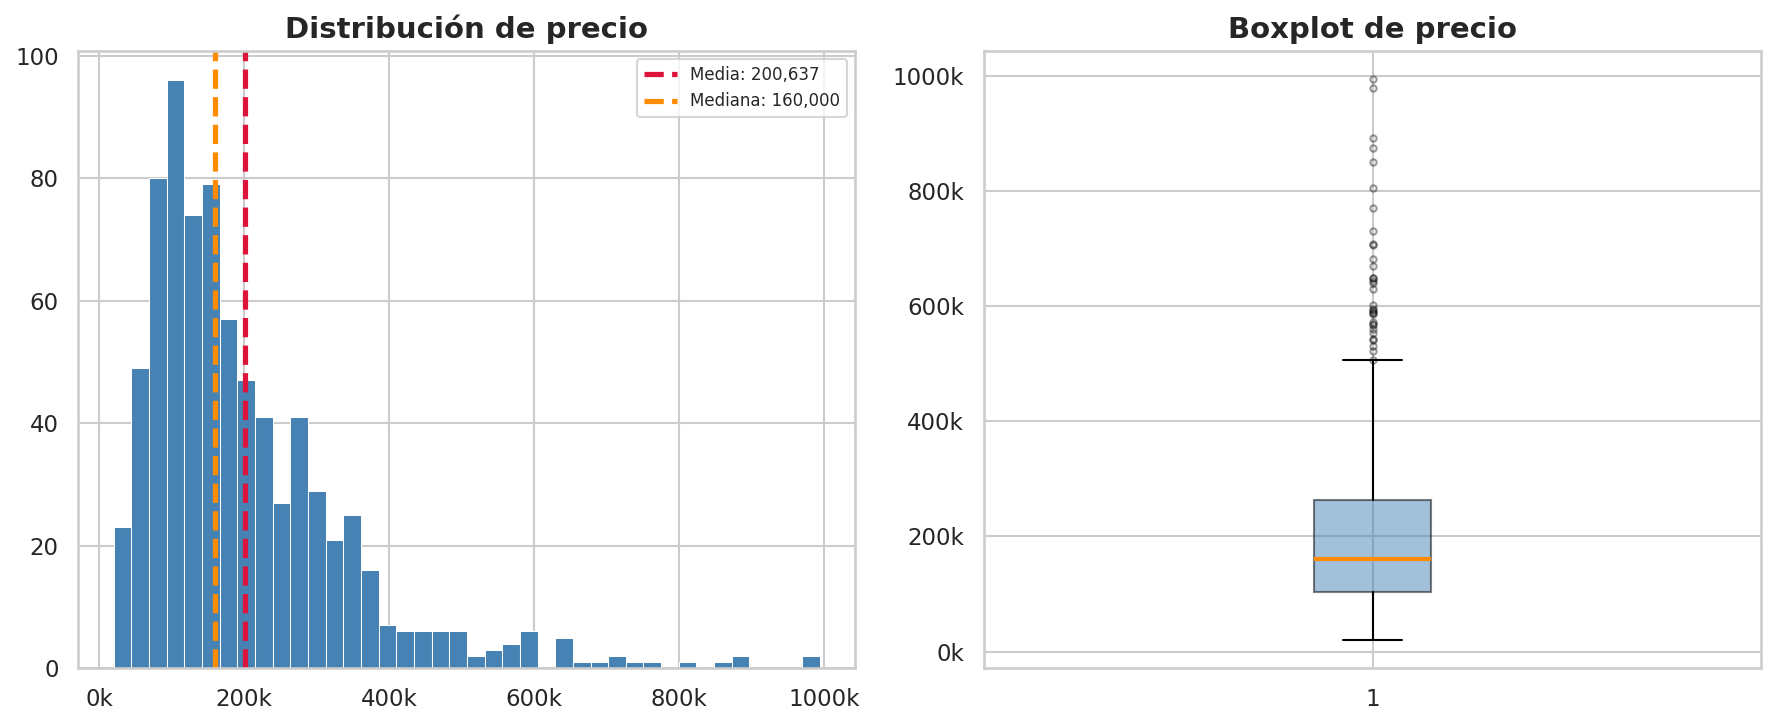

Variable: PRECIO
  > Límite superior IQR: 505,837.50
  > Outliers detectados: 33 (4.3%)
------------------------------


In [342]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

def plot_univariate_analysis(data, var, color="steelblue"):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    data_series = data[var].dropna()

    # --- 1. HISTOGRAMA ---
    axes[0].hist(data_series, bins=40, color=color, edgecolor="white", linewidth=0.5)
    mean_val = data_series.mean()
    median_val = data_series.median()
    axes[0].axvline(mean_val, color="crimson", linestyle="--", label=f"Media: {mean_val:,.0f}")
    axes[0].axvline(median_val, color="darkorange", linestyle="--", label=f"Mediana: {median_val:,.0f}")
    axes[0].set_title(f"Distribución de {var}")
    axes[0].legend(fontsize=8)
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

    # --- 2. BOXPLOT ---
    axes[1].boxplot(data_series, vert=True, patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.5),
                       medianprops=dict(color="darkorange", linewidth=2),
                       flierprops=dict(marker="o", markersize=3, alpha=0.4, color="crimson"))
    axes[1].set_title(f"Boxplot de {var}")
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

    plt.tight_layout()
    plt.show()

    # Estadísticas
    q1 = data_series.quantile(0.25)
    q3 = data_series.quantile(0.75)
    iqr = q3 - q1
    lim_sup = q3 + 1.5 * iqr
    outliers = (data_series > lim_sup).sum()
    print(f"Variable: {var.upper()}")
    print(f"  > Límite superior IQR: {lim_sup:,.2f}")
    print(f"  > Outliers detectados: {outliers} ({outliers/len(data_series)*100:.1f}%)")
    print("-" * 30)

# 1. Histograma y Boxplot de precio
plot_univariate_analysis(datasetPropiedades, 'precio')

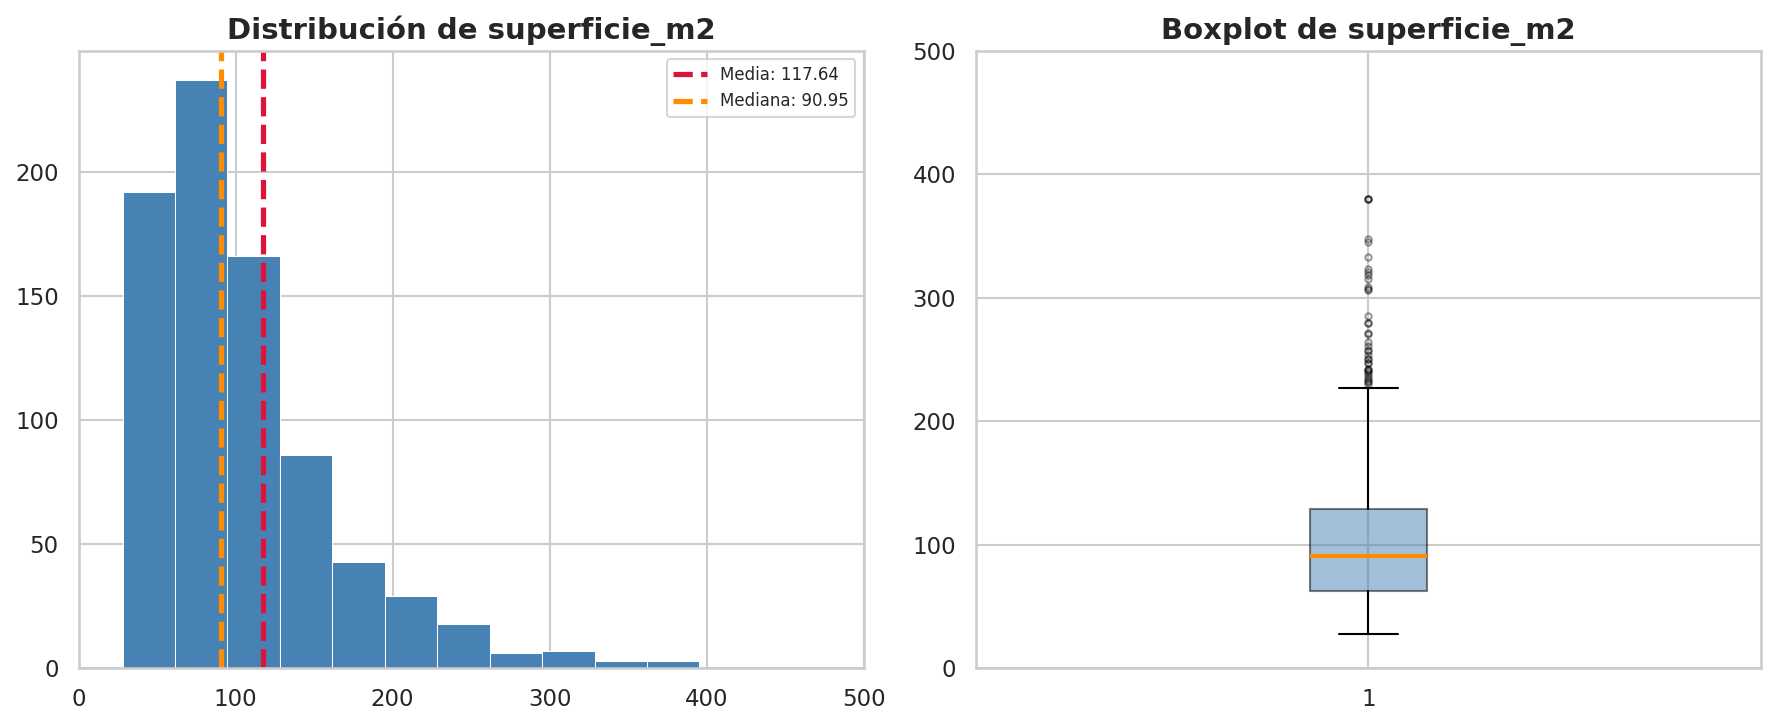

Variable: SUPERFICIE_M2
  > Límite superior IQR: 229.17
  > Outliers detectados: 47 (5.9%)
------------------------------


In [343]:
# 2. Histograma y Boxplot de superficie_m2
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
var = 'superficie_m2'
data_series = datasetPropiedades[var].dropna()
color = "steelblue"

# --- 1. HISTOGRAMA ---
axes[0].hist(data_series, bins=80, color=color, edgecolor="white", linewidth=0.5)
mean_val = data_series.mean()
median_val = data_series.median()
axes[0].axvline(mean_val, color="crimson", linestyle="--", label=f"Media: {mean_val:.2f}")
axes[0].axvline(median_val, color="darkorange", linestyle="--", label=f"Mediana: {median_val:.2f}")
axes[0].set_title(f"Distribución de {var}")
axes[0].set_xlim(0, 500)  # Ajuste de magnitud eje X
axes[0].legend(fontsize=8)

# --- 2. BOXPLOT ---
axes[1].boxplot(data_series, vert=True, patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.5),
                   medianprops=dict(color="darkorange", linewidth=2),
                   flierprops=dict(marker="o", markersize=3, alpha=0.4, color="crimson"))
axes[1].set_title(f"Boxplot de {var}")
axes[1].set_ylim(0, 500)  # Ajuste de magnitud eje Y

plt.tight_layout()
plt.show()

# Estadísticas
q1 = data_series.quantile(0.25)
q3 = data_series.quantile(0.75)
iqr = q3 - q1
lim_sup = q3 + 1.5 * iqr
outliers = (data_series > lim_sup).sum()
print(f"Variable: {var.upper()}")
print(f"  > Límite superior IQR: {lim_sup:,.2f}")
print(f"  > Outliers detectados: {outliers} ({outliers/len(data_series)*100:.1f}%)")
print("-" * 30)

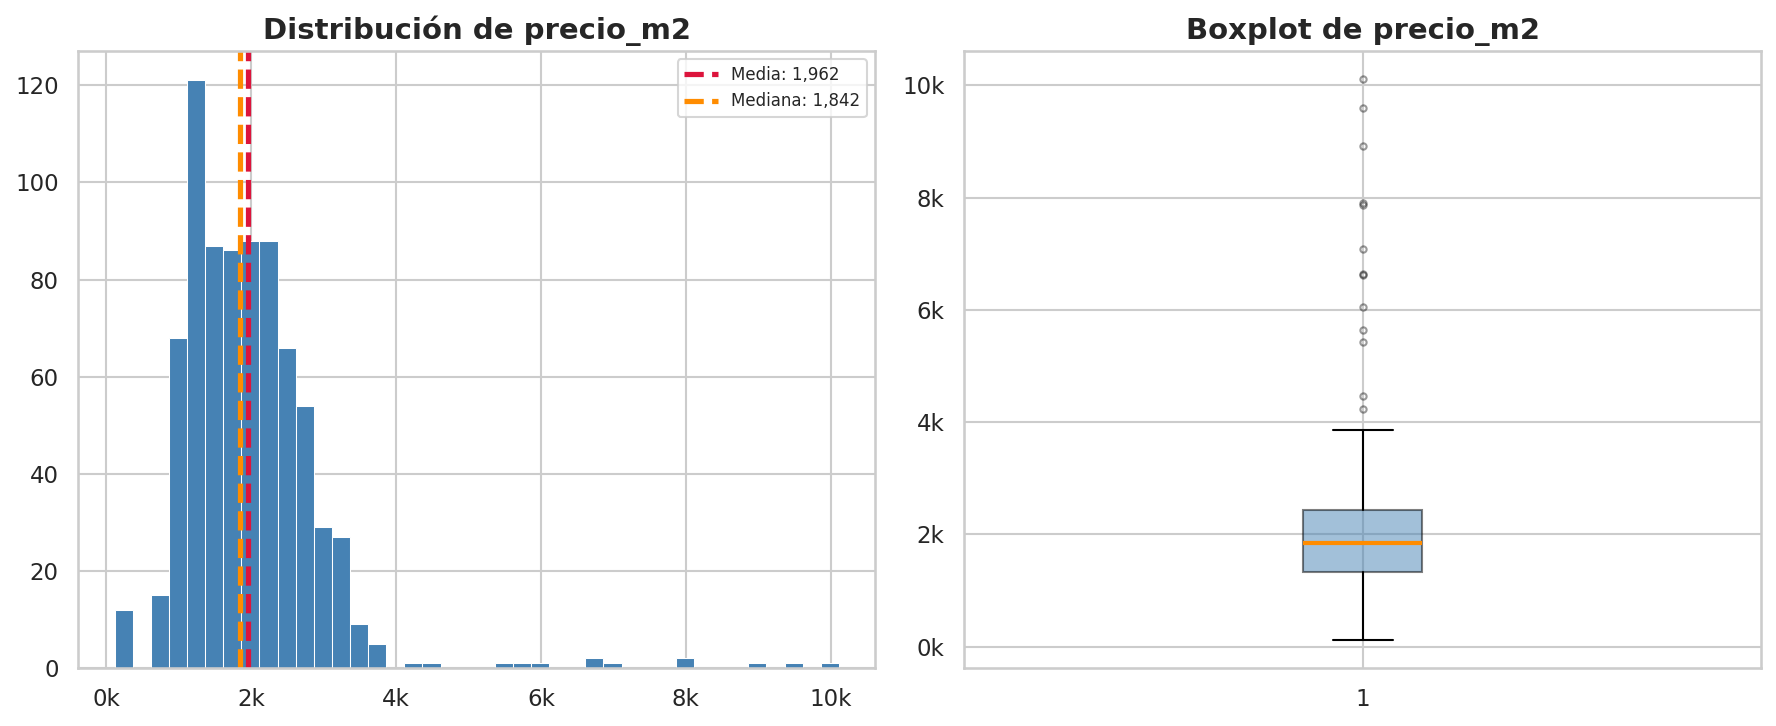

Variable: PRECIO_M2
  > Límite superior IQR: 4,106.86
  > Outliers detectados: 13 (1.7%)
------------------------------


In [344]:
# 3. Histograma y Boxplot de precio_m2
plot_univariate_analysis(datasetPropiedades, 'precio_m2')

A partir de las visualizaciones realizadas, se observa que ninguna de las variables analizadas (precio, superficie y precio por metro cuadrado) sigue una distribución normal simétrica. Los histogramas muestran un marcado sesgo a la derecha, lo que indica que la gran mayoría de la oferta inmobiliaria se concentra en un segmento masivo de valores medios a bajos (específicamente entre **80k** y **250k**), mientras que una minoría de propiedades se extiende hacia valores significaitivamente más altos, generando colas largas en la distribución.

En cuanto a la detección de outliers, el análisis de los bloxplots revela la presencia de valores atípicos en todas las variables, pero no todos deben recibir el mismo tratamiento. En la variable `superficie_m2`, se identificó un valor extremo que supera los 2500 metros cuadrados. Al cruzar este dato con la naturaleza del dataset (viviendas urbanas), se dedució que se trata de un error de carga o ruído, ya que es una cifra inusual para el contexto. Este tipo de outliers deben eliminarse para evitar que el modelo de IA genere predicciones distorsionadas por datos erróneos.

Por el contrario, los outliers detectados en la variable `precio` (propiedades que rondan el millón de dolares) y en `precio_m2` tienden a ser valores legítimos. Al analizar estos casos concretos en el dataset, se observa que corresponden a propiedades ubicadas en zonas de alta demanda o con características premium. Por lo tanto, se conservaron estos datos por que representan un segmento real del mercado de la clase alta.

En conclusión, mientras que la superficie requiere una limpieza por los errores de consistencia, las variables de precio deben mantener sus valores atípicos para que el modelo final sea capaz de reconocer y valorar correctamente las propiedades de clase alta.

---

##5. Relaciones entre variables: **(Cambiar el formato viejo)**

¿Se identifica alguna variable en el dataset que sea el resultado de una operación matemática
entre otras columnas? De ser así, ¿esta variable aportaría información nueva al análisis? ¿Qué
impacto tendría incluirla en un análisis de correlación junto con sus variables de origen? Formular
una hipótesis al respecto y luego comprobar su validez mediante el cálculo o gráfico de correlación
correspondiente.

In [345]:
# Primeras 5 filas para verificar que los datos se leyeron correctamente
datasetPropiedades.head()

,id,precio,superficie_m2,habitaciones,antiguedad_años,barrio,precio_m2
0,1,648900.0,232.9,6,5.0,Palermo,2786.17
1,2,210000.0,190.1,6,1.0,Sur,1104.68
2,3,254800.0,103.6,4,18.0,Belgrano,2459.46
3,4,594000.0,189.2,6,4.0,Palermo,3139.53
4,5,170200.0,90.6,2,45.0,Centro,1878.59


Se puede observar que si se realiza el producto entre `superficie_m2` y `precio_m2` se obtine el `precio`. No aporta información nueva `precio_m2` al estar contenida en las otras 2 variables.

Si 2 variables poseen dependencia funcional directa o colinealidad, es decir el coeficientes de correlación es muy alto. El impacto que puede causar en modelos de IA predictivos, es que se confunda al estár recibir la misma información 2 veces y desestabiliza los calculos internos, esto afecta las métricas de éxito.
Entonces si se realiza la matríz de correlación las 3 variables tendrán alto coeficiente de correlación.


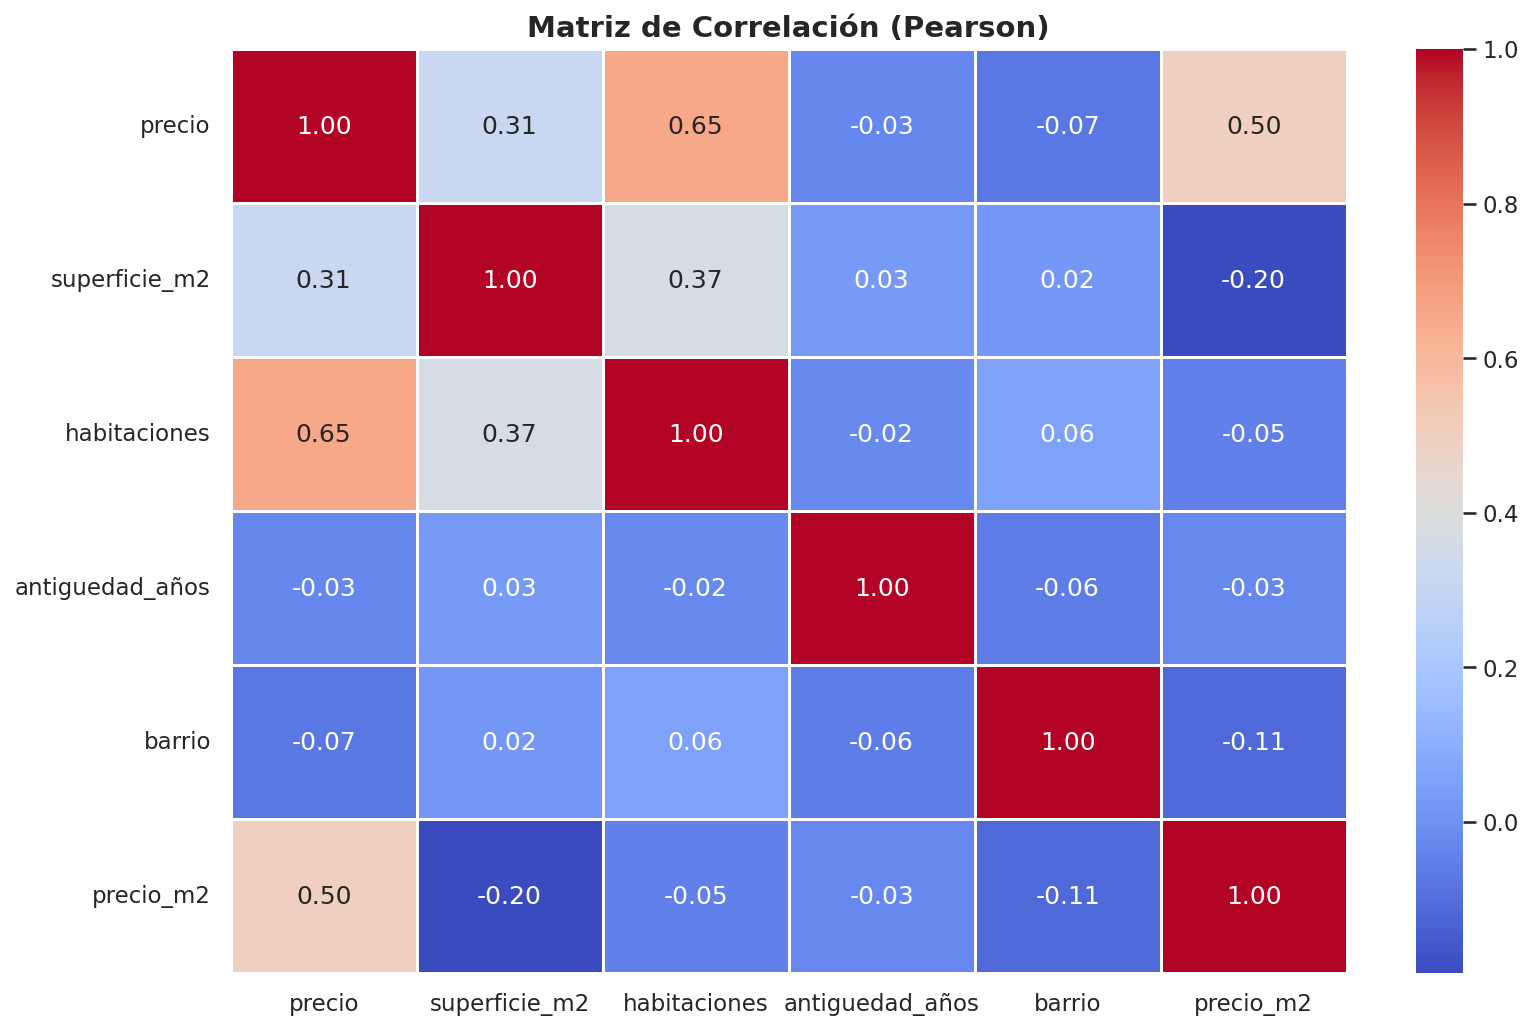

In [346]:
dataset_encoded = datasetPropiedades.copy()
le = LabelEncoder()

# Eliminamos la columna ID porque no tiene valor predictivo
dataset_encoded = dataset_encoded.drop(columns=['id'])

# Codificamos las variables categóricas, se pasa a numeros temporales debido a que aplicar la correlación estandar
# se trabaja con valores numéricos
for col in dataset_encoded.select_dtypes(include=['object', 'category', 'string']).columns:
    dataset_encoded[col] = le.fit_transform(dataset_encoded[col])

# Mostramos el mapa de calor con el coeficiente de Pearson
plt.figure(figsize=(12, 8))
sns.heatmap(dataset_encoded.corr(method='pearson'), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación (Pearson)')
plt.show()

Se puede observar que ese es el caso, si el modelo se encargase de predecir el valor de cada metro cuadrado del immueble en base a las demas variables del dataset lo mejor seria eliminar la columna del `precio_m2`.

¿Qué riesgo existiría al entrenar un algoritmo o modelo utilizando una variable de entrada que
tenga dependencia funcional directa con el valor que se quiere predecir (target)? ¿Cómo afectaría
a las métricas de éxito del modelo?  

El riesgo de entrenar un modelo con variables de entrada con dependencia directa a la variable salida (target) haria que empieze a memorizar, tomaria unicamente 2 variables de entrada en cuenta sin considerar las demás, debido a que poseen un vinculo matématico, esto se conoce como Target Leakage, porque se filtra la respuesta en dicho vinculo. Entonces el efecto de las metricas de éxito cuando comparamos con los resultados de entrenamiento puede llegar a ser perfecto, pero una vez que se le pruebe con nuevos datos el rendimiento se desploma.


¿Se observan diferencias de precio significativas entre barrios? Proponer una visualización que
permita comparar las distribuciones de precio por barrio de manera simultánea.

Lo lógico en la realidad es que los barrios mas seguros, y/o posean mas puntos de interes, sean los mas caros en cuanto al precio del immueble, entonces se puede comparar el precio promedio de cada barrio con un gráfico de barras como se muestra acontinuación.

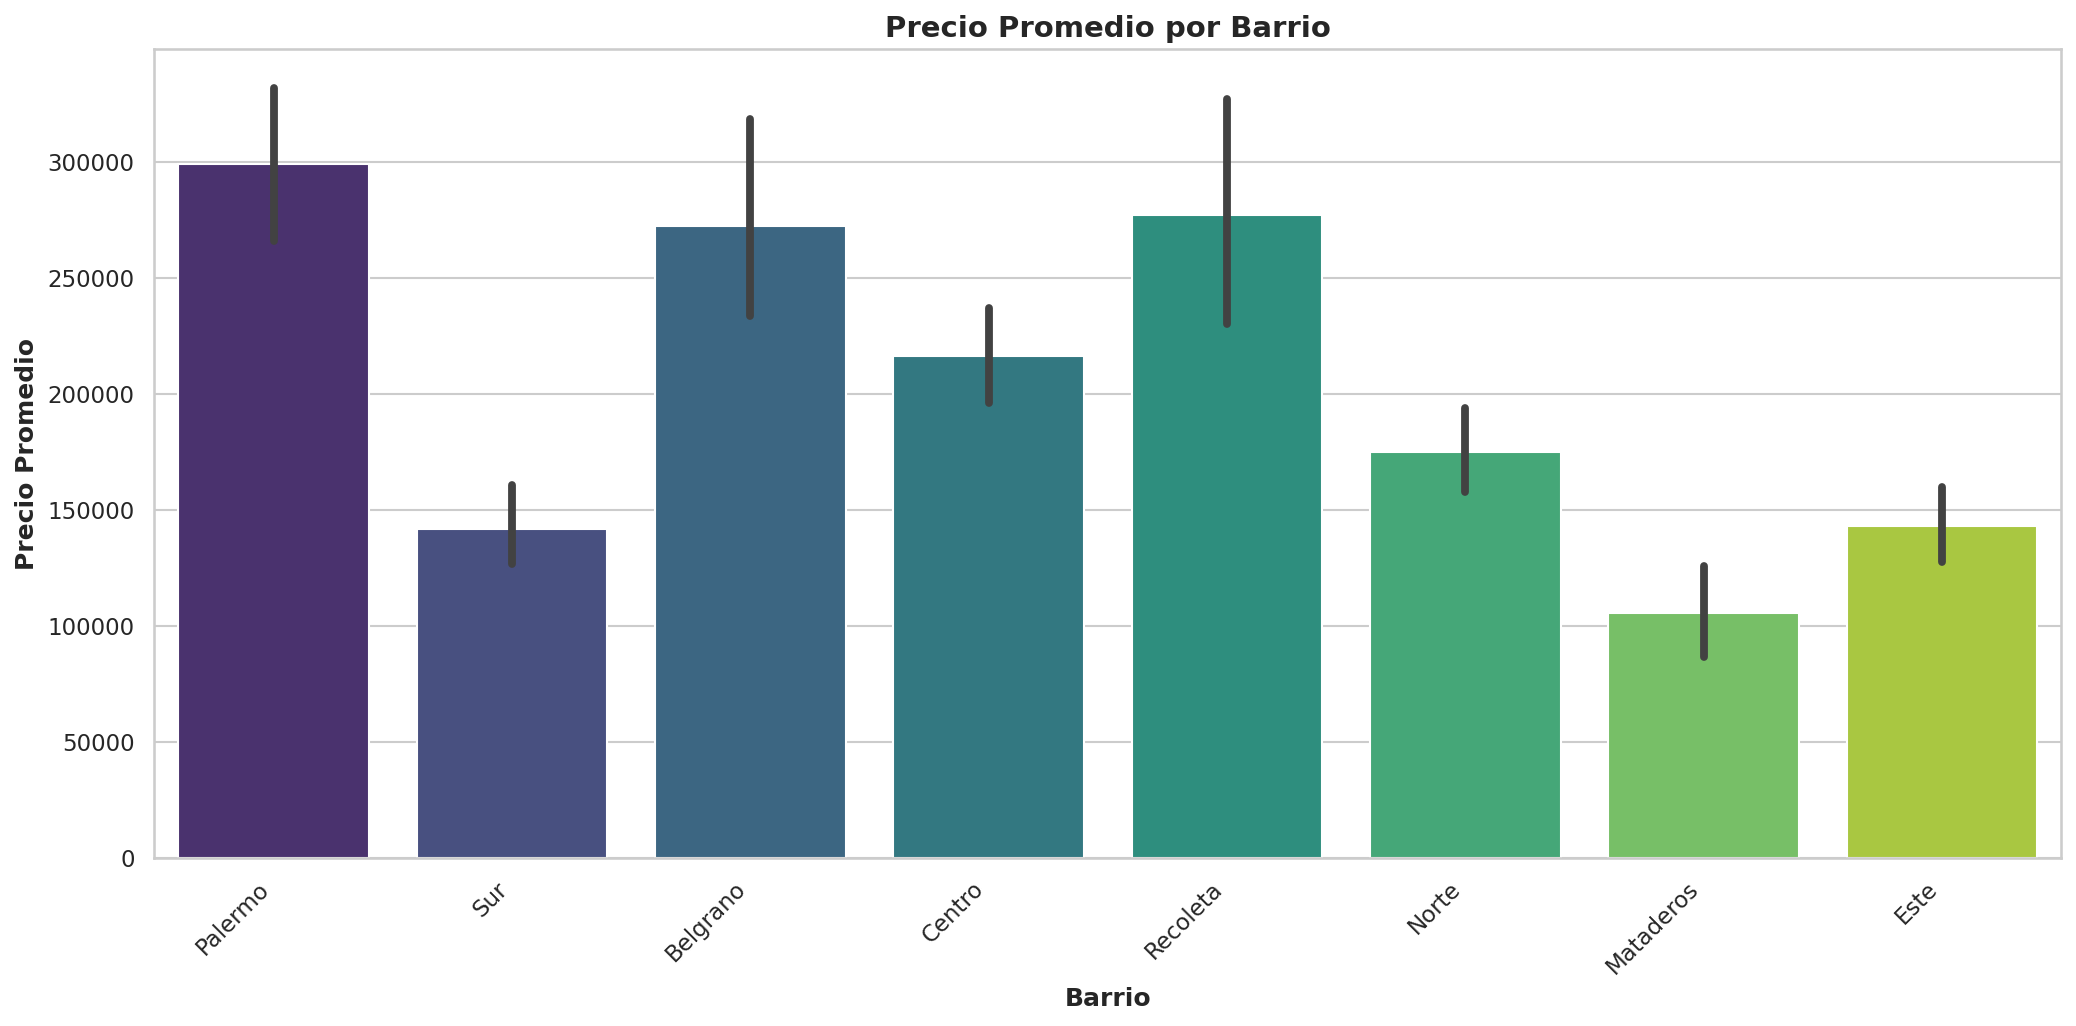

In [347]:
plt.figure(figsize=(14, 7))
sns.barplot(x='barrio', y='precio', data=datasetPropiedades, palette='viridis')
plt.title('Precio Promedio por Barrio')
plt.xlabel('Barrio')
plt.ylabel('Precio Promedio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Podemos observar que Palermo es el barrio con los precios promedios mas altos, lo cual tiene sentido según lo anteriormente explicado, y mataderos posee los precios mas bajos en promedio.

---

#Ejercicio 2: Exploración comparativa

---
**Dataset:** `clientes_chrun.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta Axel, Bareiro Santiago, Borges Agustin  
**Fecha:** xx/03/2026

>Para este ejercicio se incorpora un segundo dataset, correspondiente al historial de clientes de una empresa de telecomunicaciones con información sobre cancelación del servicio (chrun). El dataset incluye variables como antigüedad del cliente, tipo de contrato, monto mensual facturado, cantidad de productos contratados y una variable binaria que indica si el cliente abandonó el servicio:
>- churn: 0 = permanece
>- churn: 1 = se fue
>
>El dataset se encuentra en el archivo adjunto denominado **"clientes_churn.csv"**.
>El objetivo es comparar ambos datasets desde el punto de vista exploratorio, desarrollando criterio sobre las particularidades de cada uno.

---
##0. Configuracion del entorno

In [348]:
#importación del dataset requerido para el enunciado
datasetChurn = pd.read_csv("/content/clientes_churn.csv")

##1. Carga y primera inspección

In [349]:
print("Primeras 10 filas del dataset:\n")
datasetChurn.head(10)

Primeras 10 filas del dataset:



,id_cliente,antiguedad_meses,contrato,facturacion_mensual,productos,soporte_tecnico,tiene_fibra,churn
0,1001,42,anual,40.64,3.0,1,1,0
1,1002,16,mensual,68.57,2.0,1,0,1
2,1003,78,bianual,32.38,3.0,0,0,1
3,1004,9,anual,63.87,1.0,0,1,1
4,1005,1,mensual,68.47,1.0,1,1,0
5,1006,42,bianual,42.23,5.0,0,1,0
6,1007,45,anual,44.62,3.0,0,0,0
7,1008,49,anual,51.34,1.0,1,0,0
8,1009,4,mensual,30.19,1.0,0,1,1
9,1010,20,mensual,67.23,5.0,0,1,0


In [350]:
print(f"El dataset 'datasetChurn' tiene {len(datasetChurn)} registros.\n")
print("Tipos de datos por columna:")
print(datasetChurn.dtypes)

El dataset 'datasetChurn' tiene 1200 registros.

Tipos de datos por columna:
id_cliente               int64
antiguedad_meses         int64
contrato                object
facturacion_mensual    float64
productos              float64
soporte_tecnico          int64
tiene_fibra              int64
churn                    int64
dtype: object


Se cuentan 1200 registros, donde cada registro (fila) representa a un cliente individual identificado por un `id_cliente`.

Por otro lado, se cuentan 8 variables en total, las cuales se clasifican de la siguiente manera:
- `antiguedad_meses`, `mensual` y `productos` califican como variables numéricas.
- `contrato` y `soporte_tecnico` califican como variables categóricas
- `churn` califica como variable target u objetivo

en donde cada variable tiene un proposito distinto:

- `antiguedad_meses`: Es el tiempo (en meses que el cliente lleva con la empresa.
- `facturacion_mensual`: Es el monto que paga el cliente de cada mes.
- `productos`: Es la cantidad de servicios contratados.
- `contrato`: Define la relación legal del cliente con el servicio.
- `soporte_tecnico`: indica si cuenta con el servicio (1) o no (0).
- `tiene_fibra`: indica la tecnología de conexión (1: Fibra, 0:Otros).
-`churn`: Es la variable a predecir.

---
##2. Comparación general **(Alex-cambiar formato)**

- ¿Cuál de los dos datasets parece más limpio en términos de calidad de datos? ¿Por qué?

Para hacer una comparacion, primero debemos analizar los datos del dataset 'churn de clientes'.

In [351]:
# Primeras 5 filas para verificar que los datos se leyeron correctamente
datasetChurn.head()

,id_cliente,antiguedad_meses,contrato,facturacion_mensual,productos,soporte_tecnico,tiene_fibra,churn
0,1001,42,anual,40.64,3.0,1,1,0
1,1002,16,mensual,68.57,2.0,1,0,1
2,1003,78,bianual,32.38,3.0,0,0,1
3,1004,9,anual,63.87,1.0,0,1,1
4,1005,1,mensual,68.47,1.0,1,1,0


In [352]:
# Resumen de los tipos de datos y recuento de valores no nulos
datasetChurn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_cliente           1200 non-null   int64  
 1   antiguedad_meses     1200 non-null   int64  
 2   contrato             1200 non-null   object 
 3   facturacion_mensual  1164 non-null   float64
 4   productos            1140 non-null   float64
 5   soporte_tecnico      1200 non-null   int64  
 6   tiene_fibra          1200 non-null   int64  
 7   churn                1200 non-null   int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 75.1+ KB


In [353]:
# Contabilizar valores nulos por columna
datasetChurn.isna().sum()

,0
id_cliente,0
antiguedad_meses,0
contrato,0
facturacion_mensual,36
productos,60
soporte_tecnico,0
tiene_fibra,0
churn,0


In [354]:
valores_nulos_propiedades = datasetPropiedades.isna().sum()
valores_nulos_churn = datasetChurn.isna().sum()

# Calculamos el porcentaje de valores nulos
porcentaje_valores_nulos_propiedades = (valores_nulos_propiedades / len(datasetPropiedades))
porcentaje_valores_nulos_churn = (valores_nulos_churn / len(datasetChurn))

comparacion_datos_nulos = pd.DataFrame({
    'DatasetPropiedades': porcentaje_valores_nulos_propiedades,
    'DatasetChurn': porcentaje_valores_nulos_churn
})

# Display only rows with at least one missing value in either dataset
comparacion_datos_nulos = comparacion_datos_nulos[(comparacion_datos_nulos['DatasetPropiedades'] > 0) | \
                                                  (comparacion_datos_nulos['DatasetChurn'] > 0)]

print("\nPorcentaje de valores Nulos:")
display(comparacion_datos_nulos.fillna(0))


Porcentaje de valores Nulos:


,DatasetPropiedades,DatasetChurn
antiguedad_años,0.06,0.00
facturacion_mensual,0.00,0.03
precio,0.04,0.00
precio_m2,0.04,0.00
productos,0.00,0.05


In [355]:
numerical_cols = datasetChurn.select_dtypes(include=['number']).columns

# Calcular la media y la mediana para cada columna numérica
valores_media = datasetChurn[numerical_cols].mean()
valores_mediana = datasetChurn[numerical_cols].median()

# Calcular la diferencia absoluta entre la media y la mediana
diferencia = (valores_media - valores_mediana).abs()

# Calcular la diferencia porcentual
diferencia_porcentual = (diferencia / valores_mediana) * 100

# Crear un DataFrame para mostrar los resultados
diferencias_df = pd.DataFrame({
    'Media': valores_media,
    'Mediana': valores_mediana,
    'Diferencia Absoluta (Media - Mediana)': diferencia,
    'Diferencia Porcentual (%)': diferencia_porcentual
}).sort_values(by='Diferencia Porcentual (%)', ascending=False)

display(diferencias_df)

,Media,Mediana,Diferencia Absoluta (Media - Mediana),Diferencia Porcentual (%)
churn,0.326667,0.0,0.326667,inf
soporte_tecnico,0.559167,1.0,0.440833,44.083333
tiene_fibra,0.590000,1.0,0.410000,41.000000
antiguedad_meses,30.383333,24.0,6.383333,26.597222
productos,2.472807,2.0,0.472807,23.640351
facturacion_mensual,63.840275,62.4,1.440275,2.308133
id_cliente,1600.500000,1600.5,0.000000,0.000000


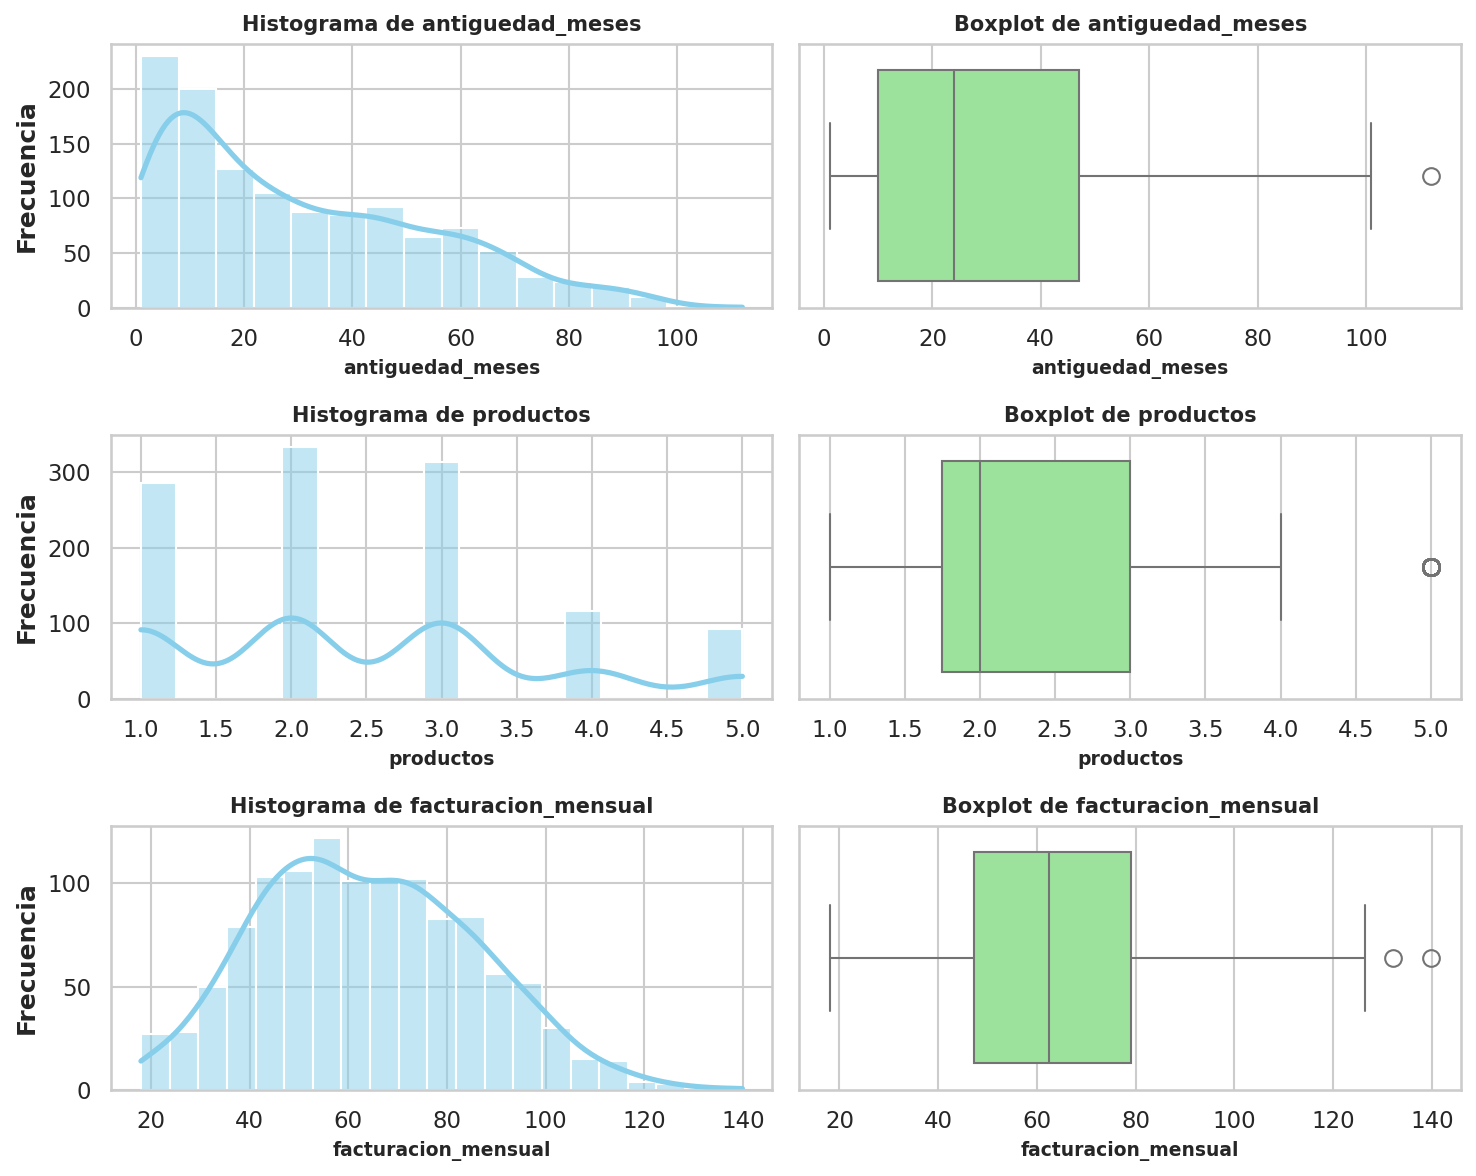

In [356]:
# carga de las 3 variables a analizar
variables = ['antiguedad_meses', 'productos', 'facturacion_mensual']

# Se definen parametros para la creación de la visualización
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))

# bucle que itera entre gráfico por variable
for i, var in enumerate(variables):

    # gráfico izquierdo (Columna 0): Histograma
    sns.histplot(data=datasetChurn, x=var, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Histograma de {var}', fontsize=10)
    axes[i, 0].set_xlabel(var, fontsize=9)

    # gráfico derecho (Columna 1): Boxplot
    sns.boxplot(data=datasetChurn, x=var, ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot de {var}', fontsize=10)
    axes[i, 1].set_xlabel(var, fontsize=9)

    axes[i,0].set_ylabel('Frecuencia')

# se ajustamos el espaciado para evitar superposiciones
plt.tight_layout()

# impresión del gráfico final
plt.show()

Como podemos observar, en el caso de `datasetChurn` tenemos menor porcentaje de valores faltantes y menos *outliers*, ademas de tener mas entradas de datos que en el caso de `datasetPropiedades`. Aparentemente, podria decirse que el dataset de churn esta mas limpio.

- ¿Cuál presenta mayor complejidad desde el punto de vista exploratorio? ¿A qué atribuyen esa complejidad?

Basandonos en los datos recopilados anteriormente, podemos decir que el dataset de propiedades tiene una mayor complejidad exploratoria, ya que posee una mayor cantidad de datos o espacios vacios que necesitan atenderse para el correcto analisis.

##3. Variables categóricas y desbalance de clases **(Borges - Cambiar formato)**

-¿Existen variables categóricas?

Sí, en el dataset de telecomunicaciones existen múltiples variables categóricas. Identificando a `contrato` como una variable categórica nominal (con valores en texto: mensual, anual, bianual). Además, existen variables categóricas bibarias que ya se encuentran codificadas numéricamente como `soporte_tecnico` (1/0) y `tiene_fibra` (1/0).

-¿Alguna de ellas domina visualmente en su distribución?

Al generar los gráficos de barras para observar la distribución de frecuencias, se detecta que la variable `contrato` es la que presenta una dominancia visual más marcada. La categoría "mensual" agrupa a mas de la mitad de los clientes (54,4%), superando a las opciones "anual" (30,4%) y "bianual" (15,2%). En contraste, las variables binarias como `tiene_fibra` y `soporte_tecnico` presentan distribuciones visualmente más equilibradas, rondando una proporción cercana al 60% - 40%.

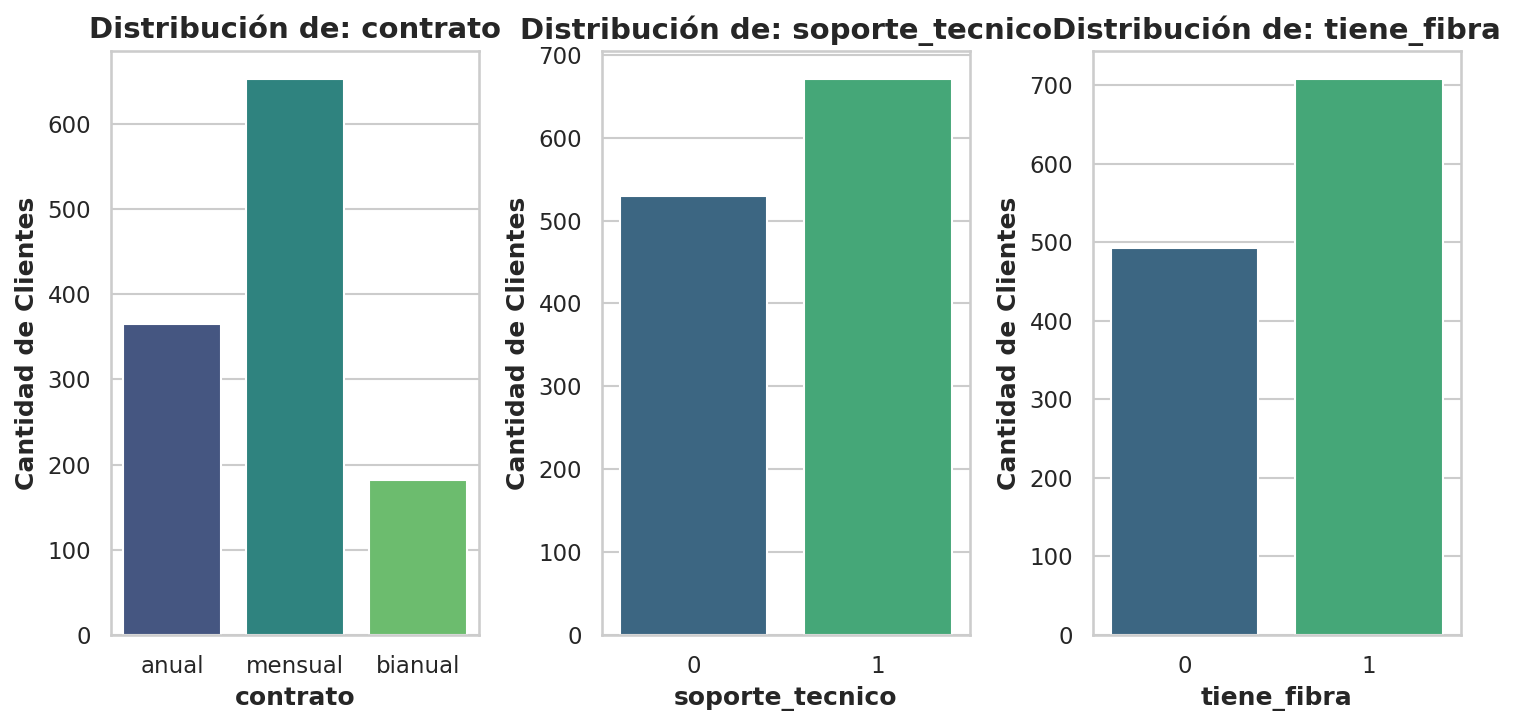

In [357]:
# Definimos cuáles son nuestras variables categóricas predictoras
variables_cat = ['contrato', 'soporte_tecnico', 'tiene_fibra', ]

# Preparamos una figura con 3 subgráficos (1 fila, 3 columnas)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 5))

# Iteramos para crear un gráfico de barras por cada variable
for i, col in enumerate(variables_cat):
    # countplot cuenta automáticamente cuántos hay de cada categoría
    sns.countplot(data=datasetChurn, x=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribución de: {col}')
    axes[i].set_ylabel('Cantidad de Clientes')

# Ajustamos el diseño y mostramos
plt.tight_layout()
plt.show()

- En el dataset de churn, ¿están las clases balanceadas? ¿Qué proporción de clientes abandonó el
servicio?

--- CANTIDAD DE CLIENTES ---
churn
0    808
1    392
Name: count, dtype: int64

--- PROPORCIÓN EXACTA (%) ---
churn
0    67.33
1    32.67
Name: proportion, dtype: float64


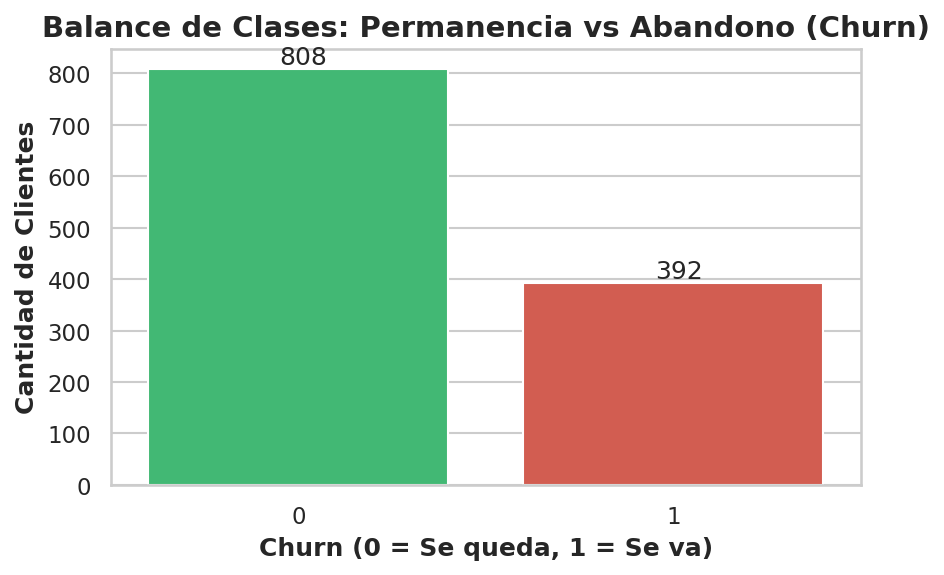

In [358]:
# 1. Análisis numérico exacto
conteo_real = datasetChurn['churn'].value_counts()
proporcion = datasetChurn['churn'].value_counts(normalize=True) * 100

print("--- CANTIDAD DE CLIENTES ---")
print(conteo_real)
print("\n--- PROPORCIÓN EXACTA (%) ---")
print(proporcion.round(2))

# 2. Gráfico para analizar visualmente el balance
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=datasetChurn, x='churn', palette=['#2ecc71', '#e74c3c'])

# Configuramos las etiquetas del gráfico
plt.title('Balance de Clases: Permanencia vs Abandono (Churn)')
plt.xlabel('Churn (0 = Se queda, 1 = Se va)')
plt.ylabel('Cantidad de Clientes')

# Agregamos los numeritos arriba de las barras para mayor claridad
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 10))

plt.tight_layout()
plt.show()

Al analizar la variable objetivo `churn`, comprobamos numéricamente y visualmente que las clases **no** se encuentran balanceadas. Existe una clara predominancia de la clase 0 (clientes que permanecen).


Sobre un total de 1200 instancias, 808 clientes decidieron quedarse y 392 decidieron darse de baja. Esto significa que el 32,76% de los clientes abandonó el servicio, frente a un 67,33% que lo mantuvo.

Esto representa un caso de desbalance moderado (una relación de 2 a 1 a favor de la clase mayoritaria).

- ¿Qué implicaría un desbalance importante de clases al momento de entrenar un modelo de clasificación? ¿Qué métricas de evaluación serían más adecuadas en ese caso?

Un desbalance importante de calses al momento de entrenar un modelo de clasificación implica un alto riesgo de generar un sesgo hacia la clase mayoritaria. El algoritmo, en su intento por minimizar el error global, aprenderá que predecir siempre la clase dominante es la estrategia más "segura".

Como consecuencia, el modelo perderá sensibilidad y fracasará en su objetivo principal, el cual es detectar los casos de la clase minoritaria (que suele ser el evento de interés comercial, en este contexto, predecir exactamente qué cliente hará churm).

En este caso, la evaluación debe basarse en el análisis de la Matriz de confusión y usar metricas especiales:

- **Sensibilidad**: Fundamental para saber qué el porcentaje del total de clientes que realmente iban a abandonar se lograron identificar a tiempo.
- **Presición**: Útil para medir la confiabilidad de las alarmas del modelo evitando así malgastar el presupuesto de retención de falsos positivos.

##4. Visualizaciones **(Santi - Falta hacer)**

(acá va el desarrollo)

---
##5. Reflexión orientada al preprocesamiento **(Alex - cambiar formato)**

- ¿Qué transformaciones o preprocesamientos serían necesarios antes de alimentar un modelo con estos datos? ¿En qué variables se utilizaría normalización/estandarización? ¿Qué variables deberían pasar por un proceso de codificación (encoding)? ¿Qué método de encoding aplicarían? ¿Hay un orden jerárquico en estas variables que deba preservarse?

Inicialmente deberiamos quitar la *feature* `id_cliente`, ya que solo aporta ruido al analisis.

Luego se deberia resolver que hacer con los espacios nulos y *outliers* de `facturacion_mensual` y `productos`. En el caso de la facturacion mensual, se puede utilizar la mediana para completar los espacios vacios y verificar si los valores atipicos son correctos o errores de tipeo.

In [359]:
clientes_con_facturacion_alta = datasetChurn[datasetChurn['facturacion_mensual'] > 120]
print(f"Cantidad de clientes con facturación mensual mayor a 120: {len(clientes_con_facturacion_alta)}")

Cantidad de clientes con facturación mensual mayor a 120: 7


Otra solucion seria simplemente eliminar los datos con un valor de facturacion mensual por sobre 120, principalmente porque son pocos datos los que perderiamos.

Para la *feature* productos podriamos simplemente usar la moda para completar los valores nulos.

In [360]:
clientes_con_5_productos = len(datasetChurn[datasetChurn['productos'] == 5])
print(f"Cantidad de clientes con 5 productos: {clientes_con_5_productos} (un {(clientes_con_5_productos/1200)*100}% de los clientes)")

Cantidad de clientes con 5 productos: 93 (un 7.75% de los clientes)


Y el valor atipico de 5 productos se repite demasiadas veces para ser un error de tipeo, lo mas probable es que existan varios usuarios que necesiten pagar 5 productos simultaneamente.

---
#Ejercicio 3 - Exploración de datos en ausencia de contexto

---
**Dataset:** `dataset_desconocido.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta Axel, Bareiro Santiago, Borges Agustin  
**Fecha:** xx/03/2026

>En este ejercicio se introduce un dataset "desconocido", en el que la relación entre las variables y el target es presuntamente no lineal y no resulta evidente a priori.
>
>El dataset contiene múltiples variables numéricas, algunas de las cuales son relevantes para predecir el target y otras son ruído puro. Además, existen valores faltantes y outliers. La variable objetivo (target) es binaria (0 o 1). El dataset se encuentra en el archivo denominado "dataset_desconocido.csv.
>
>El desafío consiste en usar  herramientas visuales y análisis explotario para descrubrir qué variables y qué tipo de relaciones determinan el target. De modo de desarrollar una intuición analítica que permita comprender el comportamiento del sistema, incluso en ausencia de un contexto previo.

---
##0. Configuracion del entorno

In [361]:
#importación del dataset requerido para el enunciado
datasetDesconocido = pd.read_csv("/content/dataset_desconocido.csv")

---
##1. Carga y primera inspección **(quien tenga tiempo**)

---
##2. Comprensión del target **(Borges - Falta hacer)**

---
##3. Correlación y sus limitaciones **(Santi - Falta hacer)**

---
##4. Exploración visual avanzada **(Alex - Falta hacer)**

---
##5. Outliers y variables irrelavantes **(Borges - Falta hacer)**

---
##6. Conclusiones Finales **(Santi - Falta hacer)**

---
# Resultados y Discusión


---
# Referencias



(Poner resultados generales y conclusión del trabajo práctico acá)

---
# Entorno de Ejecución

In [362]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
